In [3]:
import sys
!{sys.executable} -m pip install xgboost imbalanced-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


In [5]:
df = pd.read_csv('C:/Users/surya/Desktop/customer-marketing-ml/data/scaled_data.csv')

# Drop non-feature columns
drop_cols = ['KMeans_Cluster', 'Cluster_Label', 
             'Hierarchical_Cluster', 'DBSCAN_Cluster', 'GMM_Cluster']
drop_cols = [col for col in drop_cols if col in df.columns]
df = df.drop(columns=drop_cols)

# Define features and target
X = df.drop(columns=['Response'])
y = df['Response']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features shape: (2236, 32)
Target distribution:
Response
0    1902
1     334
Name: count, dtype: int64


### Handle Imbalanced data with SMOTE

In [6]:
# Remember our data was 85% rejected, 15% accepted
# SMOTE creates synthetic samples of minority class

X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X, y)

print("Before SMOTE:")
print(f"  Class 0: {(y==0).sum()}  Class 1: {(y==1).sum()}")
print("\nAfter SMOTE:")
print(f"  Class 0: {(y_resampled==0).sum()}  Class 1: {(y_resampled==1).sum()}")

Before SMOTE:
  Class 0: 1902  Class 1: 334

After SMOTE:
  Class 0: 1902  Class 1: 1902


### Train, Test and Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_resampled
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (3043, 32)
Test size:  (761, 32)


### Define all the models

In [8]:
models = {
    'Logistic Regression'    : LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors'    : KNeighborsClassifier(),
    'Naive Bayes'            : GaussianNB(),
    'Support Vector Machine' : SVC(probability=True, random_state=42),
    'Decision Tree'          : DecisionTreeClassifier(random_state=42),
    'Random Forest'          : RandomForestClassifier(random_state=42),
    'AdaBoost'               : AdaBoostClassifier(random_state=42),
    'Gradient Boosting'      : GradientBoostingClassifier(random_state=42),
    'XGBoost'                : XGBClassifier(random_state=42, eval_metric='logloss')
}

print(f"✅ {len(models)} models defined and ready to train!")

✅ 9 models defined and ready to train!


### Train and evaluate all the models

In [9]:
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_pred_prob)
    })
    
    print(f"✅ {name} done")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).round(4)
print("\n")
print("=" * 75)
print("MODEL COMPARISON")
print("=" * 75)
print(results_df.to_string(index=False))

✅ Logistic Regression done
✅ K-Nearest Neighbors done
✅ Naive Bayes done
✅ Support Vector Machine done
✅ Decision Tree done
✅ Random Forest done
✅ AdaBoost done
✅ Gradient Boosting done
✅ XGBoost done


MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
               XGBoost    0.9474     0.9570  0.9368    0.9468   0.9875
         Random Forest    0.9501     0.9407  0.9605    0.9505   0.9862
     Gradient Boosting    0.9343     0.9388  0.9289    0.9339   0.9848
              AdaBoost    0.8975     0.8932  0.9026    0.8979   0.9674
   Logistic Regression    0.8922     0.9139  0.8658    0.8892   0.9566
   K-Nearest Neighbors    0.8371     0.7678  0.9658    0.8555   0.9221
         Decision Tree    0.8817     0.8816  0.8816    0.8816   0.8849
           Naive Bayes    0.7057     0.7321  0.6474    0.6872   0.7814
Support Vector Machine    0.6675     0.7530  0.4974    0.5990   0.7216


### Visualize Model Comparison

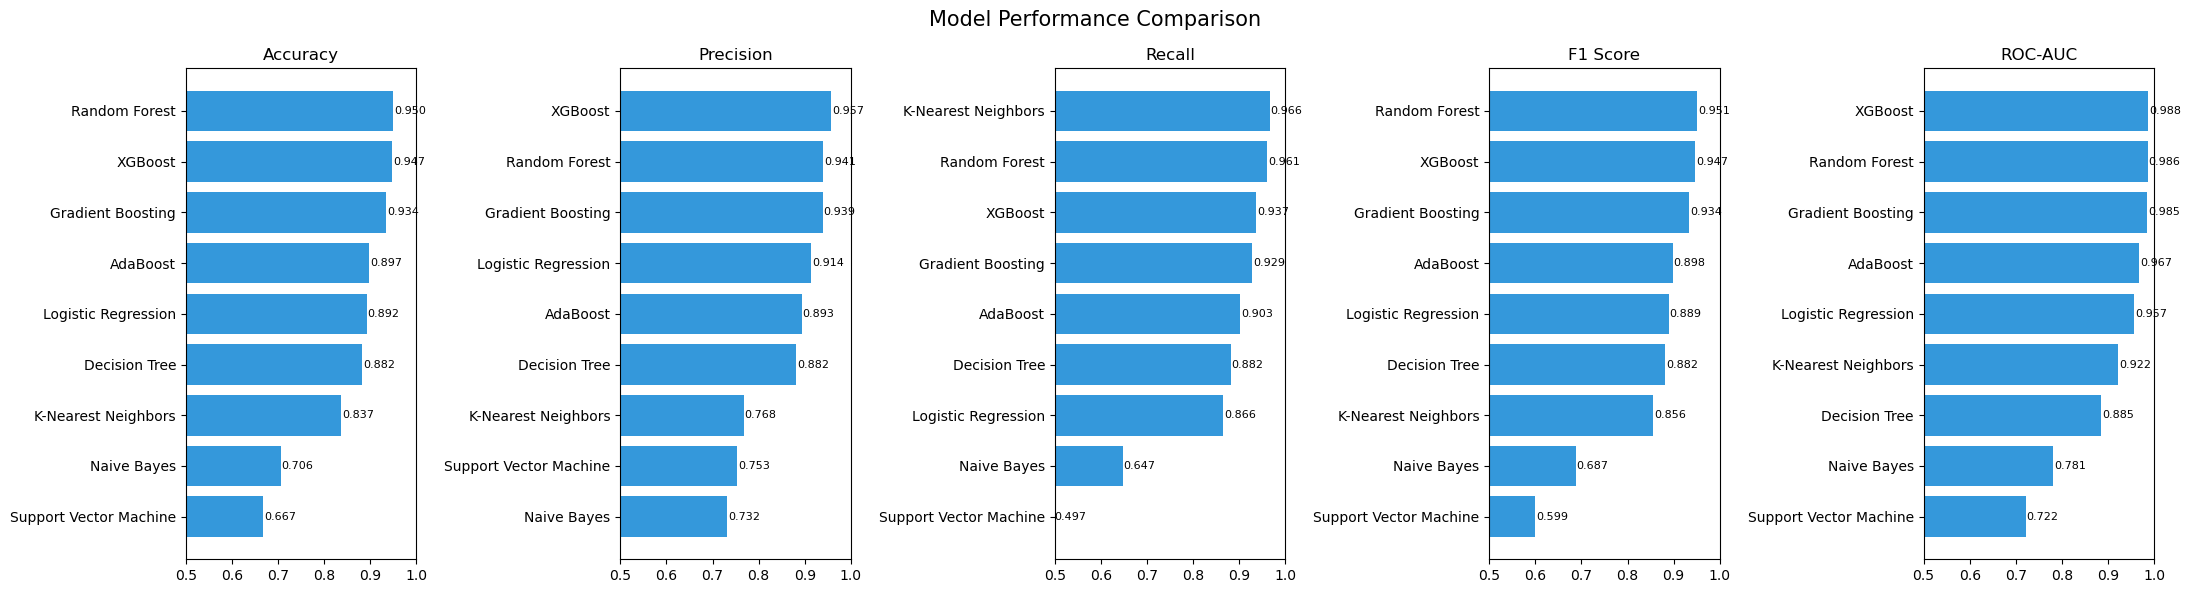

In [10]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for ax, metric in zip(axes, metrics):
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color='#3498DB')
    ax.set_title(metric, fontsize=12)
    ax.set_xlim(0.5, 1.0)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=15)
plt.tight_layout()
plt.show()

### ROC Curve

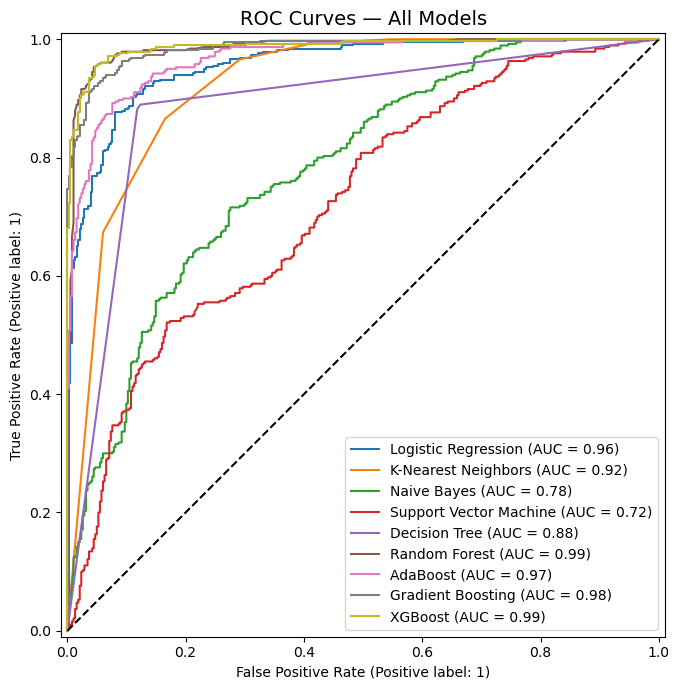

In [11]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, 
                                   ax=plt.gca(), name=name)

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.title('ROC Curves — All Models', fontsize=14)
plt.tight_layout()
plt.show()

### Hyperparameter tuning top 3 models

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# ── XGBoost ──────────────────────────────────────────
xgb_params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params, n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
print(f"\n✅ XGBoost best params:  {xgb_search.best_params_}")
print(f"   Best CV ROC-AUC:      {xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ XGBoost best params:  {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
   Best CV ROC-AUC:      0.9865


### Tune Random Forest

In [13]:
rf_params = {
    'n_estimators' : [100, 200, 300, 500],
    'max_depth'    : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features' : ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
print(f"\n✅ Random Forest best params:  {rf_search.best_params_}")
print(f"   Best CV ROC-AUC:            {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Random Forest best params:  {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
   Best CV ROC-AUC:            0.9852


### Tune Gradient Boosting

In [14]:
gb_params = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample'    : [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)
print(f"\n✅ Gradient Boosting best params:  {gb_search.best_params_}")
print(f"   Best CV ROC-AUC:               {gb_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Gradient Boosting best params:  {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 4, 'learning_rate': 0.05}
   Best CV ROC-AUC:               0.9837


### Compare Tuned vs UnTuned

In [15]:
tuned_models = {
    'XGBoost (Tuned)'          : xgb_search.best_estimator_,
    'Random Forest (Tuned)'    : rf_search.best_estimator_,
    'Gradient Boosting (Tuned)': gb_search.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    tuned_results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_pred_prob)
    })

tuned_df = pd.DataFrame(tuned_results).sort_values('ROC-AUC', ascending=False).round(4)

print("=" * 75)
print("TUNED MODEL COMPARISON")
print("=" * 75)
print(tuned_df.to_string(index=False))

TUNED MODEL COMPARISON
                    Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
          XGBoost (Tuned)    0.9527     0.9574  0.9474    0.9524   0.9907
Gradient Boosting (Tuned)    0.9488     0.9523  0.9447    0.9485   0.9901
    Random Forest (Tuned)    0.9474     0.9381  0.9579    0.9479   0.9882


### Confusion Matrix for Best Models

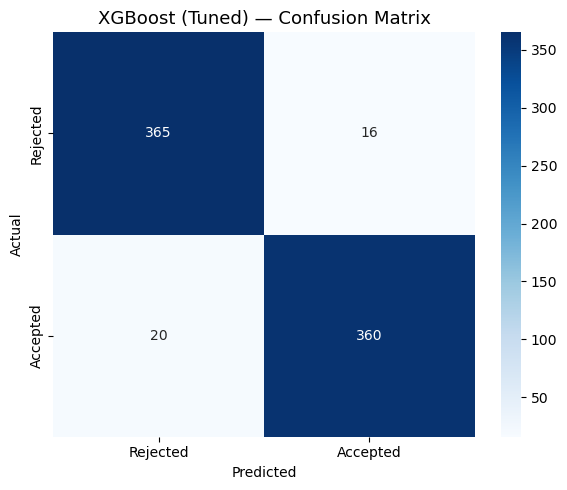


Classification Report:
              precision    recall  f1-score   support

    Rejected       0.95      0.96      0.95       381
    Accepted       0.96      0.95      0.95       380

    accuracy                           0.95       761
   macro avg       0.95      0.95      0.95       761
weighted avg       0.95      0.95      0.95       761



In [16]:
best_model = xgb_search.best_estimator_
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Accepted'],
            yticklabels=['Rejected', 'Accepted'])
plt.title('XGBoost (Tuned) — Confusion Matrix', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Accepted']))

### Cross Validation Score

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_resampled, y_resampled, 
                             cv=cv, scoring='roc_auc')

print("Cross Validation ROC-AUC Scores:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.4f}")

print(f"\n  Mean:  {cv_scores.mean():.4f}")
print(f"  Std:   {cv_scores.std():.4f}")
print(f"\n✅ Model is {'stable' if cv_scores.std() < 0.02 else 'slightly variable'} across folds")

Cross Validation ROC-AUC Scores:
  Fold 1: 0.9882
  Fold 2: 0.9876
  Fold 3: 0.9904
  Fold 4: 0.9884
  Fold 5: 0.9882

  Mean:  0.9885
  Std:   0.0009

✅ Model is stable across folds


### Saving Results

In [18]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

# Save best model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save all tuned models
with open('../models/tuned_models.pkl', 'wb') as f:
    pickle.dump({
        'XGBoost'          : xgb_search.best_estimator_,
        'Random Forest'    : rf_search.best_estimator_,
        'Gradient Boosting': gb_search.best_estimator_
    }, f)

# Save feature columns
feature_columns = list(X.columns)
with open('../models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

# Save results dataframes
results_df.to_csv('../models/all_models_results.csv', index=False)
tuned_df.to_csv('../models/tuned_models_results.csv', index=False)

print("✅ All models saved!")
print("   best_model.pkl           → XGBoost tuned model")
print("   tuned_models.pkl         → all 3 tuned models")
print("   feature_columns.pkl      → feature names")
print("   all_models_results.csv   → all 9 model results")
print("   tuned_models_results.csv → top 3 tuned results")

✅ All models saved!
   best_model.pkl           → XGBoost tuned model
   tuned_models.pkl         → all 3 tuned models
   feature_columns.pkl      → feature names
   all_models_results.csv   → all 9 model results
   tuned_models_results.csv → top 3 tuned results


## Deep Learning Imports

In [19]:
import sys
!{sys.executable} -m pip install tensorflow --quiet

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


### Build MLP Model

In [21]:
def build_mlp(input_dim):
    model = Sequential([
        # Input layer
        Dense(128, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),
        
        # Hidden layer 1
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        # Hidden layer 2
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

mlp_model = build_mlp(X_train.shape[1])
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,489 (60.50 KB)

 Trainable params: 15,041 (58.75 KB)

 Non-trainable params: 448 (1.75 KB)

### Train MLP

In [22]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss', patience=10, 
    restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, 
    patience=5, min_lr=0.00001, verbose=1
)

# Train
history = mlp_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ MLP Training complete!")

Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6027 - loss: 0.7583 - val_accuracy: 0.6634 - val_loss: 0.6419 - learning_rate: 0.0010
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6233 - loss: 0.6838 - val_accuracy: 0.6683 - val_loss: 0.6348 - learning_rate: 0.0010
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6282 - loss: 0.6695 - val_accuracy: 0.6814 - val_loss: 0.6190 - learning_rate: 0.0010
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6356 - loss: 0.6529 - val_accuracy: 0.6782 - val_loss: 0.6030 - learning_rate: 0.0010
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6664 - loss: 0.6262 - val_accuracy: 0.6798 - val_loss: 0.5935 - learning_rate: 0.0010
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6697 - loss: 0.6146 - val_accuracy: 0.6814 - val_loss: 0.5778 - learning_rate: 0.0010
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6849 - loss: 0.5979 - val_ac

### Plotting Training History

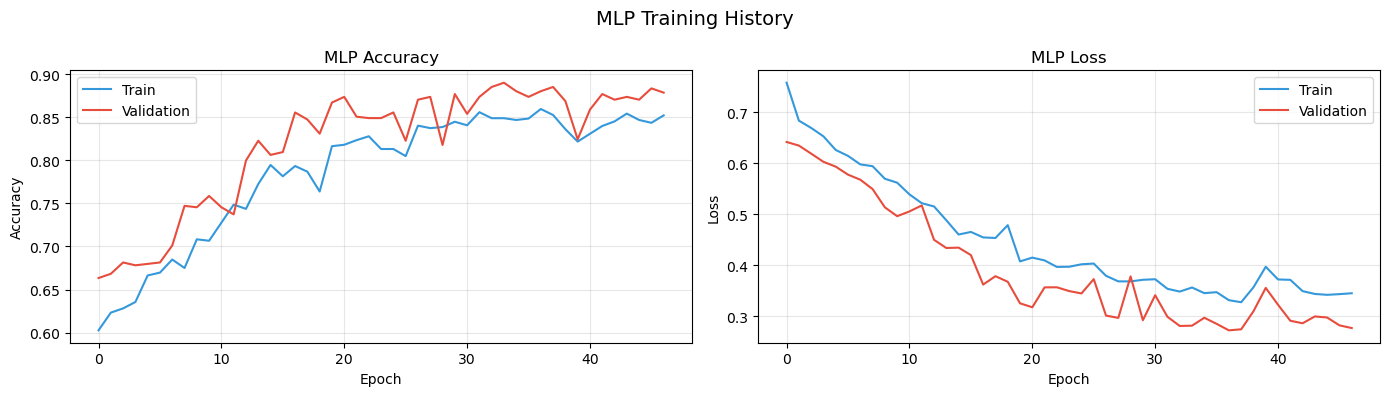

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', color='#3498DB')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#E74C3C')
axes[0].set_title('MLP Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', color='#3498DB')
axes[1].plot(history.history['val_loss'], label='Validation', color='#E74C3C')
axes[1].set_title('MLP Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('MLP Training History', fontsize=14)
plt.tight_layout()
plt.show()

### Evaluate MLP

In [24]:
# Evaluate on test set
y_pred_prob_mlp = mlp_model.predict(X_test).flatten()
y_pred_mlp      = (y_pred_prob_mlp >= 0.5).astype(int)

mlp_results = {
    'Model'    : 'MLP Neural Network',
    'Accuracy' : accuracy_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall'   : recall_score(y_test, y_pred_mlp),
    'F1 Score' : f1_score(y_test, y_pred_mlp),
    'ROC-AUC'  : roc_auc_score(y_test, y_pred_prob_mlp)
}

print("=" * 50)
print("MLP NEURAL NETWORK RESULTS")
print("=" * 50)
for metric, value in mlp_results.items():
    if metric != 'Model':
        print(f"  {metric:<12}: {value:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MLP NEURAL NETWORK RESULTS
  Accuracy    : 0.8988
  Precision   : 0.8741
  Recall      : 0.9316
  F1 Score    : 0.9019
  ROC-AUC     : 0.9547


### MLP vs Best ML Model

MLP vs XGBoost (Best ML Model)


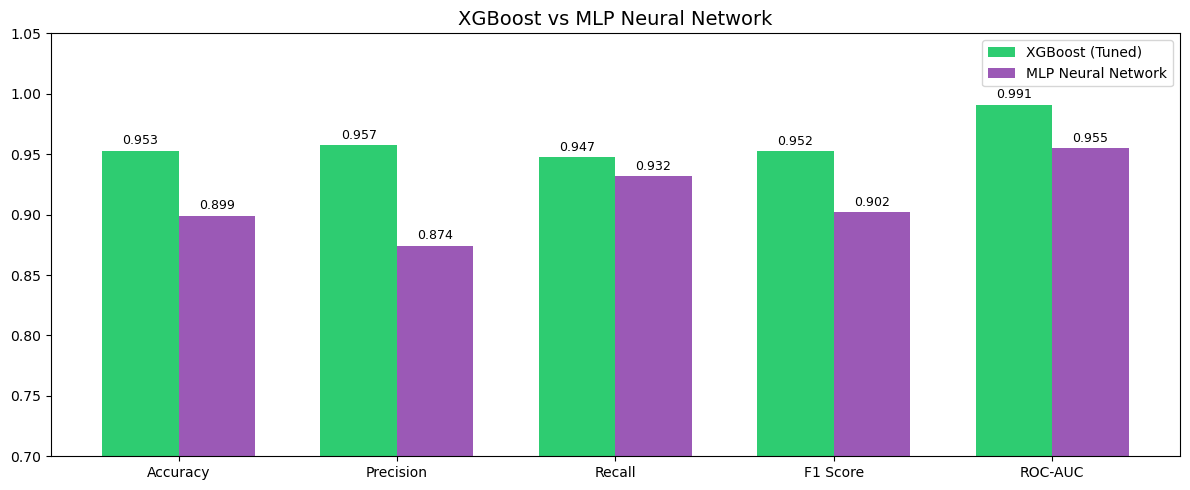


  XGBoost ROC-AUC:  0.9907
  MLP ROC-AUC:      0.9547

🏆 Winner: XGBoost


In [25]:
print("=" * 55)
print("MLP vs XGBoost (Best ML Model)")
print("=" * 55)

xgb_results = tuned_df[tuned_df['Model'] == 'XGBoost (Tuned)'].iloc[0]

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
mlp_vals = [mlp_results[m] for m in metrics]
xgb_vals = [xgb_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12, 5))
bars1 = plt.bar(x - width/2, xgb_vals, width, label='XGBoost (Tuned)', color='#2ECC71')
bars2 = plt.bar(x + width/2, mlp_vals, width, label='MLP Neural Network', color='#9B59B6')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.xticks(x, metrics)
plt.ylim(0.7, 1.05)
plt.title('XGBoost vs MLP Neural Network', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n  XGBoost ROC-AUC:  {xgb_results['ROC-AUC']:.4f}")
print(f"  MLP ROC-AUC:      {mlp_results['ROC-AUC']:.4f}")
winner = 'XGBoost' if xgb_results['ROC-AUC'] > mlp_results['ROC-AUC'] else 'MLP'
print(f"\n🏆 Winner: {winner}")

### Save MLP Model

In [26]:
mlp_model.save('../models/mlp_model.keras')
print("✅ MLP model saved → mlp_model.keras")

✅ MLP model saved → mlp_model.keras
